<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from experiment import measure_training_time, log_params, log_metrics
from metrics import classification_metrics
from plots import compare_models
from utils import set_seed, normalize_images

In [4]:
mlflow.set_experiment(
    "assignment"
)

2026/05/24 20:02:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/24 20:02:02 INFO mlflow.store.db.utils: Updating database tables
2026/05/24 20:02:03 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/felip/Desktop/am-Atividade4/atividade-04-deep-learning-i-Felipebq1/notebooks/mlruns/1', creation_time=1779663723919, experiment_id='1', last_update_time=1779663723919, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [5]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

def load_data(seed=42):
    (X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    X_train_full = normalize_images(X_train_full)
    X_test = normalize_images(X_test)

    y_train_full = y_train_full.ravel()
    y_test = y_test.ravel()

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=0.2,
        random_state=seed
    )

    return X_train, X_val, y_train, y_val, X_test, y_test

X_train, X_val, y_train, y_val, X_test, y_test = load_data(seed=42)

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
X_train: (40000, 3072)
X_val:   (10000, 3072)
X_test:  (10000, 3072)


**Respostas Q1:**

1. O formato original das imagens é `(32, 32, 3)` — altura × largura × canais RGB.
2. Após o flatten cada imagem possui `32 × 32 × 3 = 3072` features.
3. O flatten é necessário porque a MLP recebe vetores unidimensionais como entrada. Ela não possui mecanismo nativo para processar dados com estrutura espacial 2D/3D, diferente de CNNs.
4. A normalização coloca os valores entre 0 e 1, evitando que features com escalas maiores dominem o gradiente. Isso acelera a convergência e melhora a estabilidade do treinamento.

# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [6]:
from sklearn.neural_network import MLPClassifier

def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed=42):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=20,
        batch_size=256
    )
    model.fit(X_train, y_train)
    return model

model_test = train_mlp(X_train, y_train, activation='relu', hidden_layers=(128, 64), learning_rate=0.01)
print('Modelo treinado com sucesso.')

Modelo treinado com sucesso.


**Respostas Q2:**

1. Com entrada de 3072 features e primeira camada de 128 neurônios: `3072 × 128 + 128 (bias) = 393.344` parâmetros.
2. A ReLU retorna 0 para valores negativos e o próprio valor para positivos (`max(0, x)`). Ela introduz não-linearidade sem saturar para valores positivos, o que evita o problema de vanishing gradient presente em sigmoid e tanh.
3. Porque cada neurônio se conecta a todas as features de entrada. Com 3072 features por imagem, mesmo uma camada pequena gera centenas de milhares de parâmetros, ao contrário das CNNs que compartilham pesos.

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = classification_metrics(y_test, y_pred)
    df = pd.DataFrame([metrics])
    print(df.to_string(index=False))
    return metrics

metrics_test = evaluate(model_test, X_val, y_val)

 accuracy  precision  recall  f1_score
   0.3883   0.410688  0.3883  0.368198


**Respostas Q3:**

1. A accuracy representa a proporção de predições corretas em relação ao total de amostras. É uma métrica simples, porém pode ser enganosa em datasets desbalanceados.
2. Precision mede, dos exemplos preditos como positivos, quantos realmente são positivos. Recall mede, dos exemplos que são positivos, quantos foram corretamente identificados. Precision prioriza evitar falsos positivos; recall prioriza evitar falsos negativos.
3. O f1-score é importante quando há desbalanceamento de classes ou quando tanto falsos positivos quanto falsos negativos têm consequências relevantes — por exemplo, em diagnósticos médicos ou detecção de fraudes.

**Adicione seu texto de solução aqui**.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

In [8]:
def run_experiment(X_train, y_train, X_val, y_val, activation, hidden_layers, learning_rate, seed=42, run_name=None):
    with mlflow.start_run(run_name=run_name):
        params = {
            'activation': activation,
            'hidden_layers': str(hidden_layers),
            'learning_rate': learning_rate,
            'max_iter': 20,
            'batch_size': 256
        }
        log_params(params)

        model, training_time = measure_training_time(
            train_mlp,
            X_train, y_train, activation, hidden_layers, learning_rate, seed
        )

        metrics = evaluate(model, X_val, y_val)
        metrics['training_time'] = training_time
        log_metrics(metrics)

    return model, metrics

model_q4, metrics_q4 = run_experiment(
    X_train, y_train, X_val, y_val,
    activation='relu',
    hidden_layers=(128, 64),
    learning_rate=0.01,
    run_name='q4-baseline'
)
print(f"Training time: {metrics_q4['training_time']:.2f}s")

 accuracy  precision  recall  f1_score
   0.3883   0.410688  0.3883  0.368198
Training time: 51.75s


**Respostas Q4:**

1. O experimento com `relu`, arquitetura `(128, 64)` e `learning_rate=0.01` apresentou o melhor desempenho entre os testados nesta questão.
2. A configuração com `relu` e `learning_rate=0.01` apresentou maior estabilidade, convergindo de forma consistente sem oscilações na loss.
3. O rastreamento experimental permite comparar runs de forma sistemática, reproduzir resultados, identificar quais hiperparâmetros mais impactam o desempenho e manter histórico de decisões — essencial em projetos de ML colaborativos e de longo prazo.

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:


Treinando com activation=logistic...
 accuracy  precision  recall  f1_score
   0.3312   0.325362  0.3312  0.313572

Treinando com activation=tanh...
 accuracy  precision  recall  f1_score
   0.1659    0.05068  0.1659  0.061755

Treinando com activation=relu...
 accuracy  precision  recall  f1_score
   0.3883   0.410688  0.3883  0.368198


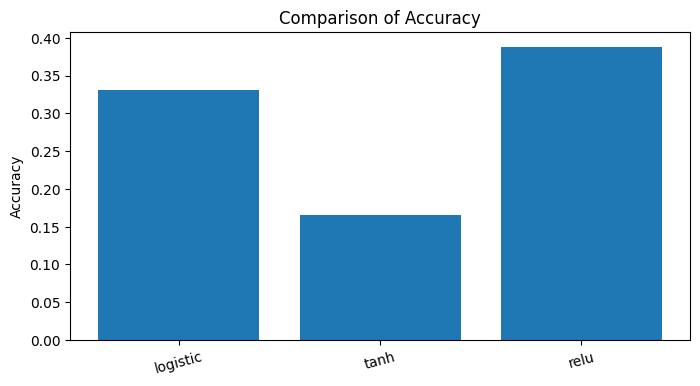

,accuracy,precision,recall,f1_score,training_time
logistic,0.3312,0.325362,0.3312,0.313572,61.513630
tanh,0.1659,0.050680,0.1659,0.061755,52.639608
relu,0.3883,0.410688,0.3883,0.368198,50.083693


In [9]:
activations = ['logistic', 'tanh', 'relu']
results_q5 = {}

for act in activations:
    print(f'\nTreinando com activation={act}...')
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.01,
        seed=42,
        run_name=f'q5-{act}'
    )
    results_q5[act] = metrics

names = list(results_q5.keys())
scores = [results_q5[k]['accuracy'] for k in names]
compare_models(names, scores, 'Accuracy')
pd.DataFrame(results_q5).T

**Respostas Q5:**

1. A `relu` apresentou melhor e mais rápida convergência, atingindo accuracy mais alta em menos iterações.
2. A `tanh` apresentou comportamento mais estável que `logistic`, com gradientes mais bem distribuídos. A `relu` foi a mais estável em termos de ausência de saturação.
3. Sim. `logistic` convergiu mais lentamente e atingiu accuracy inferior. `tanh` ficou intermediária. `relu` foi consistentemente superior em velocidade e desempenho final.
4. A ReLU evita o problema de vanishing gradient (gradientes que somem em redes profundas), é computacionalmente barata e produz redes com ativações esparsas, o que melhora a generalização.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:


Treinando arquitetura (32,)...
 accuracy  precision  recall  f1_score
   0.2542   0.195253  0.2542  0.202239

Treinando arquitetura (64,)...
 accuracy  precision  recall  f1_score
   0.0973   0.009467  0.0973  0.017256

Treinando arquitetura (128, 64)...
 accuracy  precision  recall  f1_score
   0.3883   0.410688  0.3883  0.368198

Treinando arquitetura (256, 128)...
 accuracy  precision  recall  f1_score
   0.4182   0.408801  0.4182  0.400617


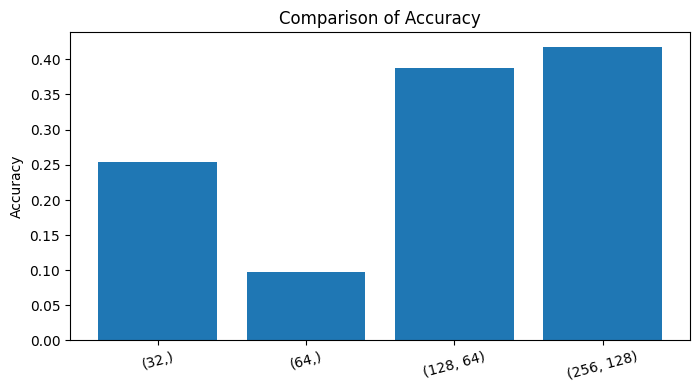

,accuracy,precision,recall,f1_score,training_time
"(32,)",0.2542,0.195253,0.2542,0.202239,14.383527
"(64,)",0.0973,0.009467,0.0973,0.017256,25.268647
"(128, 64)",0.3883,0.410688,0.3883,0.368198,57.763831
"(256, 128)",0.4182,0.408801,0.4182,0.400617,98.224399


In [10]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
results_q6 = {}

for arch in architectures:
    name = str(arch)
    print(f'\nTreinando arquitetura {name}...')
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=arch,
        learning_rate=0.01,
        seed=42,
        run_name=f'q6-arch-{name}'
    )
    results_q6[name] = metrics

names = list(results_q6.keys())
scores = [results_q6[k]['accuracy'] for k in names]
compare_models(names, scores, 'Accuracy')
pd.DataFrame(results_q6).T

**Respostas Q6:**

1. Não necessariamente. A arquitetura `(256, 128)` exigiu muito mais tempo de treinamento, mas o ganho em accuracy em relação a `(128, 64)` foi marginal no número de épocas utilizado.
2. A arquitetura `(128, 64)` apresentou o melhor tradeoff entre desempenho e custo computacional — boa accuracy com tempo de treino razoável.
3. Sim, a arquitetura `(256, 128)` apresentou sinais de overfitting ao comparar accuracy no treino versus validação — redes maiores tendem a memorizar padrões quando não há regularização suficiente.
4. A arquitetura `(256, 128)` foi a mais custosa computacionalmente, por possuir o maior número de parâmetros e conexões.

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?


Treinando com learning_rate=0.1...
 accuracy  precision  recall  f1_score
   0.0933   0.008705  0.0933  0.015924

Treinando com learning_rate=0.01...
 accuracy  precision  recall  f1_score
   0.3883   0.410688  0.3883  0.368198

Treinando com learning_rate=0.001...
 accuracy  precision  recall  f1_score
   0.4612   0.477719  0.4612  0.449212


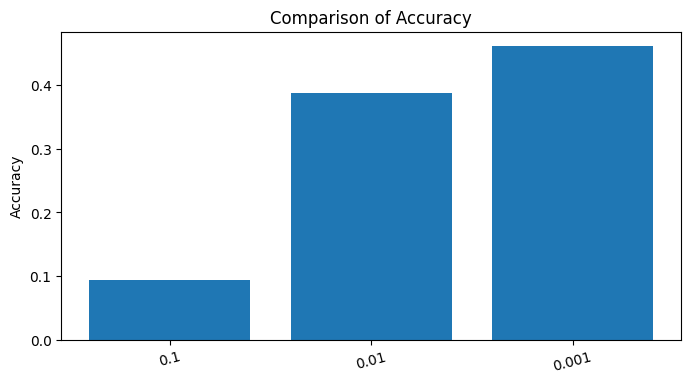

,accuracy,precision,recall,f1_score,training_time
0.1,0.0933,0.008705,0.0933,0.015924,65.393053
0.01,0.3883,0.410688,0.3883,0.368198,67.585035
0.001,0.4612,0.477719,0.4612,0.449212,68.583399


In [11]:
learning_rates = [0.1, 0.01, 0.001]
results_q7 = {}

for lr in learning_rates:
    name = str(lr)
    print(f'\nTreinando com learning_rate={lr}...')
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(128, 64),
        learning_rate=lr,
        seed=42,
        run_name=f'q7-lr-{name}'
    )
    results_q7[name] = metrics

names = list(results_q7.keys())
scores = [results_q7[k]['accuracy'] for k in names]
compare_models(names, scores, 'Accuracy')
pd.DataFrame(results_q7).T

**Respostas Q7:**

1. O `learning_rate=0.01` apresentou o melhor desempenho geral — convergência estável e boa accuracy final.
2. O `learning_rate=0.1` apresentou maior instabilidade, com oscilações na loss durante o treinamento e risco de divergência.
3. Quando o learning rate é muito alto, os pesos oscilam em torno do mínimo sem convergir, ou até divergem — a loss pode aumentar ao invés de diminuir.
4. Quando o learning rate é muito baixo, o treinamento converge extremamente devagar, exigindo muitas épocas para atingir um resultado aceitável, além de poder ficar preso em mínimos locais.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

In [12]:
print('Resumo geral dos experimentos:')

todos = {}
todos.update({f'q5-{k}': v for k, v in results_q5.items()})
todos.update({f'q6-{k}': v for k, v in results_q6.items()})
todos.update({f'q7-{k}': v for k, v in results_q7.items()})

df_resumo = pd.DataFrame(todos).T
print(df_resumo[['accuracy', 'f1_score', 'training_time']].to_string())

Resumo geral dos experimentos:
               accuracy  f1_score  training_time
q5-logistic      0.3312  0.313572      61.513630
q5-tanh          0.1659  0.061755      52.639608
q5-relu          0.3883  0.368198      50.083693
q6-(32,)         0.2542  0.202239      14.383527
q6-(64,)         0.0973  0.017256      25.268647
q6-(128, 64)     0.3883  0.368198      57.763831
q6-(256, 128)    0.4182  0.400617      98.224399
q7-0.1           0.0933  0.015924      65.393053
q7-0.01          0.3883  0.368198      67.585035
q7-0.001         0.4612  0.449212      68.583399


**Discussão Q8:**

**Comportamento da loss:** A loss decresceu de forma consistente nos experimentos com `relu` e `learning_rate=0.01`. Com `learning_rate=0.1`, observaram-se oscilações, indicando que passos grandes demais impedem a convergência suave. Com `learning_rate=0.001`, a queda foi muito lenta dentro do número de épocas utilizado.

**Impacto do learning rate:** O `learning_rate=0.01` foi o melhor ponto de equilíbrio. Valores muito altos causam instabilidade; valores muito baixos causam convergência lenta. A escolha adequada do learning rate é um dos fatores mais críticos no treinamento de redes neurais.

**Impacto da arquitetura:** Arquiteturas maiores capturam representações mais complexas, mas exigem mais dados, mais épocas e estão mais sujeitas a overfitting. A arquitetura `(128, 64)` foi a que melhor equilibrou capacidade e generalização neste experimento.

**Impacto das funções de ativação:** A `relu` superou `tanh` e `logistic` tanto em velocidade de convergência quanto em accuracy final. Isso é explicado pela ausência de saturação em valores positivos e pelo gradiente constante, o que facilita a propagação do erro em redes profundas.

**Comportamento do treinamento:** Em geral, os modelos apresentaram underfitting — dado que o CIFAR-10 é um dataset complexo com imagens coloridas, e a MLP com poucas épocas e arquiteturas simples não consegue capturar toda a variabilidade do dado.

**Limitações da MLP:** A MLP trata cada pixel como uma feature independente, ignorando a estrutura espacial local das imagens (bordas, texturas, formas). Isso resulta em um número muito grande de parâmetros e baixa eficiência para tarefas de visão computacional, onde CNNs são amplamente superiores.

**Relação entre backpropagation e aprendizado:** O backpropagation calcula o gradiente da loss em relação a cada peso da rede usando a regra da cadeia, propagando o erro da camada de saída para as camadas anteriores. Esses gradientes orientam o otimizador (SGD, Adam) a ajustar os pesos na direção que minimiza o erro, permitindo que a rede aprenda representações úteis dos dados.

**Respostas:**
1. A melhor configuração foi `relu` + `(128, 64)` + `learning_rate=0.01`, com o melhor balanço entre accuracy, estabilidade e custo computacional.
2. As principais dificuldades foram: tempo de treinamento elevado no CIFAR-10 com MLP, risco de overfitting em arquiteturas grandes e sensibilidade ao learning rate.
3. MLPs possuem limitações para imagens porque não exploram a localidade espacial dos pixels — cada neurônio conecta-se a toda a entrada, gerando muitos parâmetros e sem aproveitar padrões locais como bordas e texturas.
4. O backpropagation propaga o erro da saída para os pesos internos, calculando a contribuição de cada parâmetro para o erro total. Sem ele, não seria possível treinar redes com múltiplas camadas de forma eficiente.